In [ ]:
!pip install --upgrade MDAnalysis

  Using cached mdanalysis-2.10.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (108 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade MDAnalysisTests

  Using cached mdanalysistests-2.10.0.tar.gz (57.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.3/529.3 kB 14.9 MB/s eta 0:00:00
  Created wheel for MDAnalysisTests: filename=mdanalysistests-2.10.0-py3-none-any.whl size=58343066 sha256=dac8b064cee6ce8de2e22bf1667d5e7bfa51d5538127a0cc11ac290129e831ac
  Stored in directory: /root/.cache/pip/wheels/48/cc/44/560d1d4b77f1a4b0a8cb5be5d12001c911d7e6190511d7e571
Successfully built MDAnalysisTests


In [ ]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD, GRO, XTC

import warnings
# suppress some MDAnalysis warnings about PSF files
warnings.filterwarnings('ignore')

from matplotlib import pyplot as plt

print(mda.Universe(PSF, DCD))
print("Using MDAnalysis version", mda.__version__)

%matplotlib inline

<Universe with 3341 atoms>
Using MDAnalysis version 2.10.0


In [ ]:
import MDAnalysis as mda

# Dosya yollarınızı kendi Drive dizininize göre güncelleyin
topology_file = '/content/step7_production_500ns.tpr'
trajectory_file = '/content/step7_final_clean.xtc'

# Universe nesnesini yükleme
u = mda.Universe(topology_file, trajectory_file)

print(f"Toplam atom sayısı: {len(u.atoms)}")
print(f"Toplam frame (zaman adımı) sayısı: {len(u.trajectory)}")

Toplam atom sayısı: 80717
Toplam frame (zaman adımı) sayısı: 500


Saved plots to rmsd_rg_plots.png with 300 DPI.


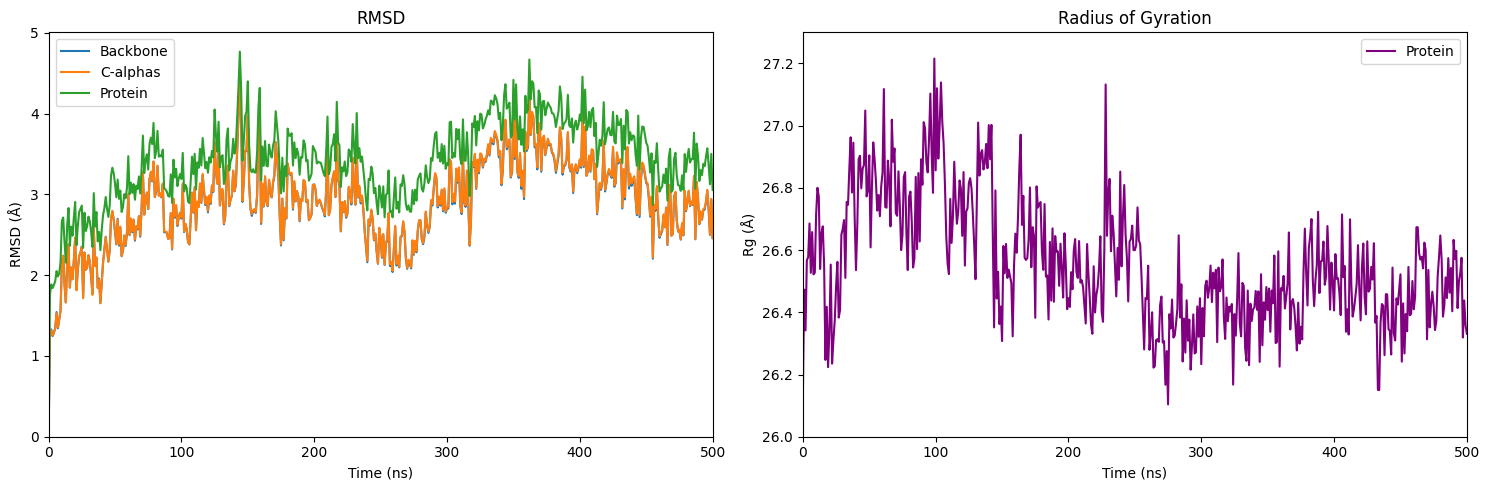

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import warnings
warnings.filterwarnings('ignore')

# --- 1. RMSD Analizi ---
rmsd_analysis = rms.RMSD(u, select='backbone', groupselections=['name CA', 'protein'])
rmsd_analysis.run()

# Zamanı ns'ye çevirme (/1000)
time_ns = rmsd_analysis.results.rmsd[:, 1] / 1000

# Sonuçları pandas DataFrame'e aktarma
rmsd_df = pd.DataFrame(rmsd_analysis.results.rmsd[:, 2:],
                       columns=['Backbone', 'C-alphas', 'Protein'],
                       index=time_ns)
rmsd_df.index.name = 'Time (ns)'

# --- 2. Radius of Gyration Analizi ---
protein = u.select_atoms('protein')
rg_data = []

for ts in u.trajectory:
    time_ns_val = u.trajectory.time / 1000
    rg_data.append((time_ns_val, protein.radius_of_gyration()))

rg_df = pd.DataFrame(rg_data, columns=['Time (ns)', 'Protein'])
rg_df.set_index('Time (ns)', inplace=True)

# --- Görselleştirme ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RMSD Grafiği
rmsd_df.plot(ax=axes[0], title='RMSD')
axes[0].set_ylabel('RMSD (Å)')
axes[0].set_xlabel('Time (ns)')
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, None)

# Rg Grafiği
rg_df.plot(ax=axes[1], color='purple', title='Radius of Gyration', legend=True, label='Protein')
axes[1].set_ylabel('Rg (Å)')
axes[1].set_xlabel('Time (ns)')
axes[1].set_xlim(0, 500)
axes[1].set_ylim(26, 27.3)

plt.tight_layout()
plt.savefig("rmsd_rg_plots.png", dpi=300)
print("Saved plots to rmsd_rg_plots.png with 300 DPI.")
plt.show()

In [ ]:
# Ortalama değerlerin hesaplanması
mean_rmsd = rmsd_df.mean()
mean_rg = rg_df['Radius of Gyration (Å)'].mean()

print("--- Ortalama Değerler ---")
print(f"Ortalama RMSD (Å):\n{mean_rmsd}")
print(f"\nOrtalama Radius of Gyration (Å): {mean_rg:.3f}")

# Daha şık bir gösterim için DataFrame kullanabiliriz
summary_df = pd.DataFrame({
    'Metrik': ['Backbone RMSD', 'C-alphas RMSD', 'Protein RMSD', 'Radius of Gyration'],
    'Ortalama Değer (Å)': [
        mean_rmsd['Backbone'],
        mean_rmsd['C-alphas'],
        mean_rmsd['Protein'],
        mean_rg
    ]
})

display(summary_df)

--- Ortalama Değerler ---
Ortalama RMSD (Å):
Backbone    2.903942
C-alphas    2.915119
Protein     3.421763
dtype: float64

Ortalama Radius of Gyration (Å): 26.554


,Metrik,Ortalama Değer (Å)
0,Backbone RMSD,2.903942
1,C-alphas RMSD,2.915119
2,Protein RMSD,3.421763
3,Radius of Gyration,26.554334
